In [130]:
import time
from time import sleep, monotonic
import datetime
import numpy as np
import matplotlib.pyplot as plt
import sys
import pyvisa
import qcodes as qc
from qcodes.dataset import Measurement
from qcodes.dataset import do0d
from qcodes.dataset.experiment_container import new_experiment, load_experiment_by_name
from qcodes.dataset.plotting import plot_by_id
from qcodes.dataset.data_set import load_by_id, load_by_counter
from qcodes import initialise_or_create_database_at, new_data_set, new_experiment
from qcodes.station import Station
from ipywidgets import interact, IntSlider
initialise_or_create_database_at("./2026-05-11_SNSPD12.db")
import snspd
params = snspd.snspd('snspd12.yaml')
from scipy.signal import find_peaks
import numpy as np

# Set up experiment
exp_name = 'SNSPD12_29_05_2026'
sample_name = '00'

try:
    exp = qc.load_experiment_by_name(exp_name, sample=sample_name)
    print('Experiment loaded. Last ID no:', exp.last_counter)
except ValueError:
    exp = new_experiment(exp_name, sample_name)
    print('Started new experiment')

Experiment loaded. Last ID no: 317


In [141]:
import importlib
importlib.reload(snspd)
params = snspd.snspd('snspd12.yaml')

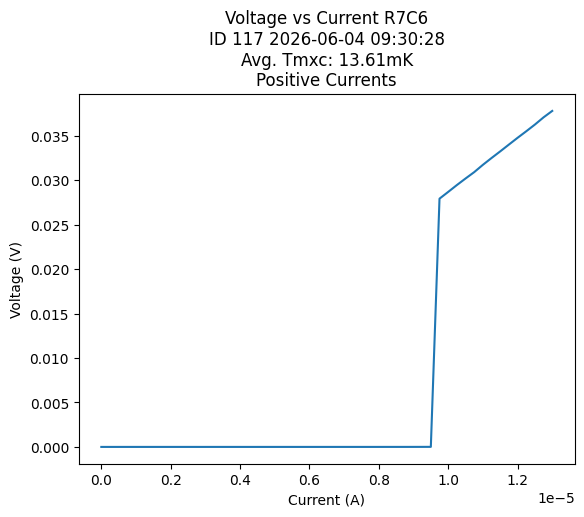

In [142]:
params.plot_critical_current(ID=117,extra='Positive Currents')

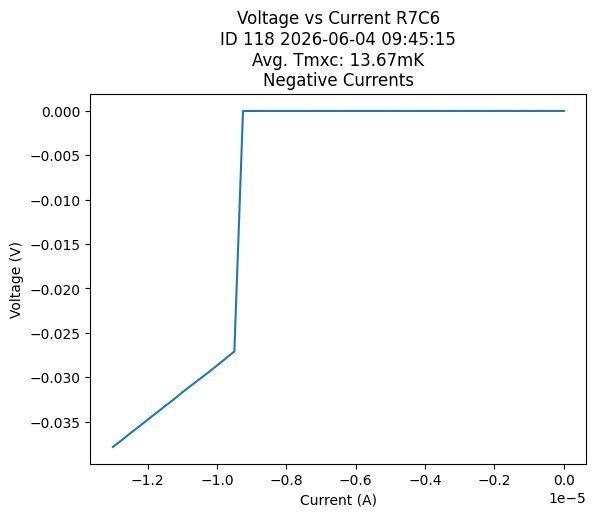

In [143]:
params.plot_critical_current(ID=118,extra='Negative Currents')

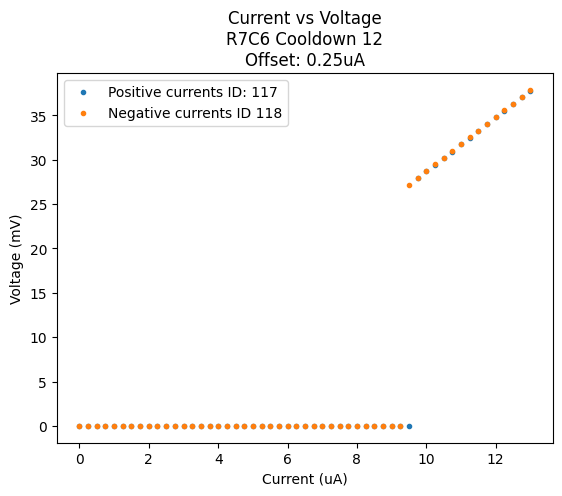

In [128]:
IDpos = 117
IDneg = 118
data = load_by_id(IDpos).get_parameter_data()
current_pos = data['dmm_volt']['yoko_current']*1e6
voltage_pos = data['dmm_volt']['dmm_volt']*1e3

data = load_by_id(IDneg).get_parameter_data()
current_neg = data['dmm_volt']['yoko_current']*1e6
voltage_neg = data['dmm_volt']['dmm_volt']*1e3

plt.plot(current_pos, voltage_pos, '.', label=f'Positive currents ID: {IDpos}')
plt.plot(-current_neg, -voltage_neg, '.', label=f'Negative currents ID {IDneg}')
plt.ylabel('Voltage (mV)')
plt.xlabel('Current (uA)')
plt.title(f'Current vs Voltage\n{params.device_line_2['name']} Cooldown 12\nOffset: {np.abs(np.diff(current_neg)[0])}uA') 
plt.legend()
# one 

In [22]:
data = load_by_id(170).get_parameter_data()
trace = data['trace']['trace']
taxis = data['trace']['time_axis']

In [53]:
# get peak 
from scipy.signal import find_peaks
import numpy as np

def plot_traces(ID):
    data = load_by_id(ID).get_parameter_data()
    trace = data['trace']['trace']
    taxis = data['trace']['time_axis']
    current = data['yoko_current']['yoko_current']
    trigger = data['trigger']['trigger'][0]
    plt.plot(taxis, trace)
    peaks, properties = find_peaks(trace, height=float(trigger), distance=len(trace))
    plt.plot(taxis, np.ones_like(taxis)*float(trigger), label=f'Trigger in sweep {trigger*1e3}mV')
    plt.plot(taxis[peaks],trace[peaks], 'ro', label='Peak')
    plt.title(f'ID: {ID} Current: {current[0]*1e6}uA')
    plt.legend()
    # plt.ylabel('Voltage (V)')
    # plt.xlabel('Time (s)')
    print(current, trace[peaks], 0.8*trace[peaks], 0.5*trace[peaks])
    print(f'Peak voltage: {trace[peaks]}')

interact(plot_traces, ID=IntSlider(min=121, max=173, step=1, value=121,
                                  continuous_update=False));

interactive(children=(IntSlider(value=121, continuous_update=False, description='ID', max=173, min=121), Outpu…

([<Axes: title={'center': 'Run #174, Experiment SNSPD12_29_05_2026 (00)'}, xlabel='Current ($10^{-6}$ I)', ylabel='cps'>,
  <Axes: title={'center': 'Run #174, Experiment SNSPD12_29_05_2026 (00)'}, xlabel='Current ($10^{-6}$ I)', ylabel='cps'>],
 [None, None])

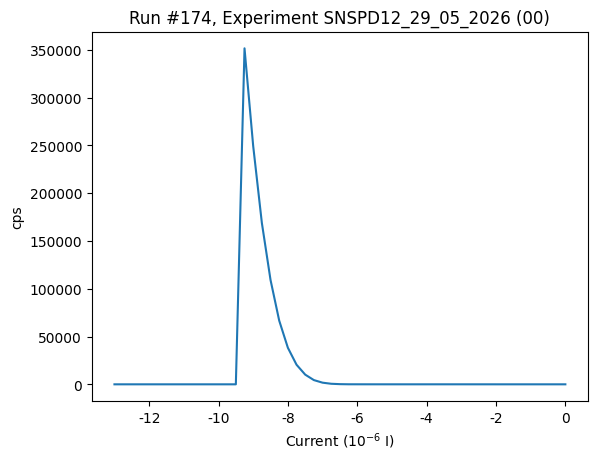

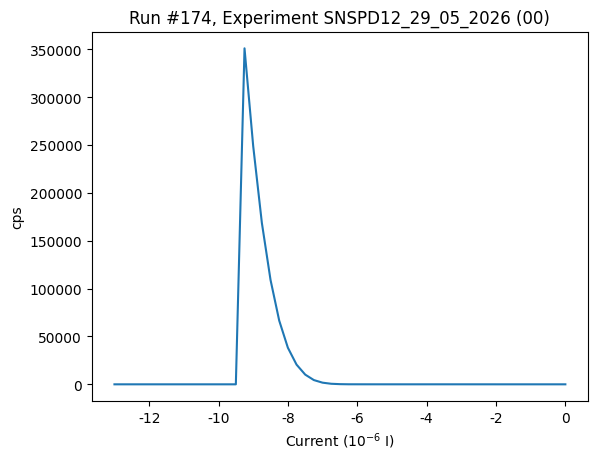

In [11]:
plot_by_id(174)

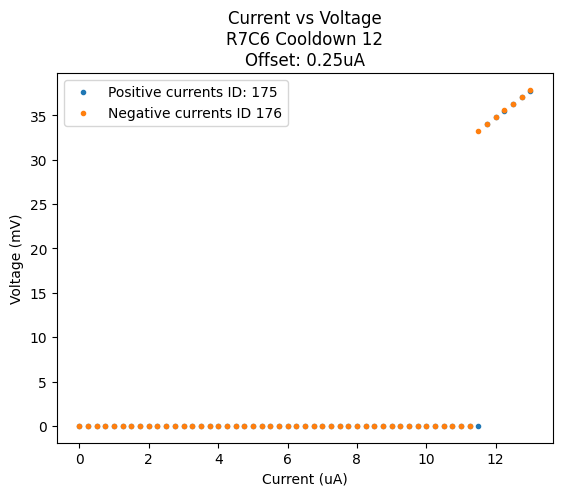

In [129]:
IDpos = 175
IDneg = 176
data = load_by_id(IDpos).get_parameter_data()
current_pos = data['dmm_volt']['yoko_current']*1e6
voltage_pos = data['dmm_volt']['dmm_volt']*1e3

data = load_by_id(IDneg).get_parameter_data()
current_neg = data['dmm_volt']['yoko_current']*1e6
voltage_neg = data['dmm_volt']['dmm_volt']*1e3

plt.plot(current_pos, voltage_pos, '.', label=f'Positive currents ID: {IDpos}')
plt.plot(-current_neg, -voltage_neg, '.', label=f'Negative currents ID {IDneg}')
plt.title(f'Current vs Voltage\n{params.device_line_2['name']} Cooldown 12\nOffset: {np.abs(np.diff(current_neg)[0])}uA') 
plt.ylabel('Voltage (mV)')
plt.xlabel('Current (uA)')
plt.legend()

In [56]:
# get peak 
from scipy.signal import find_peaks
import numpy as np

def plot_traces(ID):
    data = load_by_id(ID).get_parameter_data()
    trace = data['trace']['trace']
    taxis = data['trace']['time_axis']
    current = data['yoko_current']['yoko_current']
    trigger = data['trigger']['trigger'][0]
    plt.plot(taxis, trace)
    peaks, properties = find_peaks(trace, height=float(trigger), distance=len(trace))
    plt.plot(taxis, np.ones_like(taxis)*float(trigger), label=f'Trigger in sweep {trigger*1e3}mV')
    plt.plot(taxis[peaks],trace[peaks], 'ro', label='Peak')
    plt.title(f'ID: {ID} Current: {current[0]*1e6}uA')
    plt.legend()
    # plt.ylabel('Voltage (V)')
    # plt.xlabel('Time (s)')
    print(current, trace[peaks], 0.8*trace[peaks], 0.2*trace[peaks])
    print(f'Peak voltage: {trace[peaks]}')

interact(plot_traces, ID=IntSlider(min=177, max=230, step=1, value=121,
                                  continuous_update=False));

interactive(children=(IntSlider(value=177, continuous_update=False, description='ID', max=230, min=177), Outpu…

Current where threshold (102mV = 17*0.006) first starts counting is -5uA. 

Set the absolute minimum trigger based on the last current before latching and see if that works for low currents.

[-1.15e-05] [0.264] [0.2112] [0.0528]
Peak voltage: [0.264]


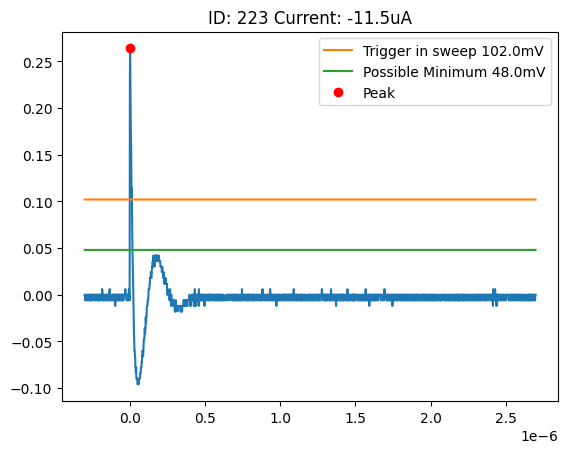

In [62]:
ID = 223
data = load_by_id(ID).get_parameter_data()
trace = data['trace']['trace']
taxis = data['trace']['time_axis']
current = data['yoko_current']['yoko_current']
trigger = data['trigger']['trigger'][0]
plt.plot(taxis, trace)
peaks, properties = find_peaks(trace, height=float(trigger), distance=len(trace))
plt.plot(taxis, np.ones_like(taxis)*float(trigger), label=f'Trigger in sweep {trigger*1e3}mV')
min_trig = 8*0.006
plt.plot(taxis, np.ones_like(taxis)*min_trig, label=f'Possible Minimum {min_trig*1e3}mV')
plt.plot(taxis[peaks],trace[peaks], 'ro', label='Peak')
plt.title(f'ID: {ID} Current: {current[0]*1e6}uA')
plt.legend()
# plt.ylabel('Voltage (V)')
# plt.xlabel('Time (s)')
print(current, trace[peaks], 0.8*trace[peaks], 0.2*trace[peaks])
print(f'Peak voltage: {trace[peaks]}')


Trigger thing

In [63]:
# get peak 
from scipy.signal import find_peaks
import numpy as np

def plot_traces(ID):
    data = load_by_id(ID).get_parameter_data()
    trace = data['trace']['trace']
    taxis = data['trace']['time_axis']
    current = data['yoko_current']['yoko_current']
    trigger = data['trigger']['trigger'][0]
    plt.plot(taxis, trace)
    peaks, properties = find_peaks(trace, height=float(trigger), distance=len(trace))
    plt.plot(taxis, np.ones_like(taxis)*float(trigger), label=f'Trigger in sweep {trigger*1e3}mV')
    plt.plot(taxis[peaks],trace[peaks], 'ro', label='Peak')
    plt.title(f'ID: {ID} Current: {current[0]*1e6}uA')
    plt.legend()
    # plt.ylabel('Voltage (V)')
    # plt.xlabel('Time (s)')
    print(current, trace[peaks], 0.8*trace[peaks], 0.2*trace[peaks])
    print(f'Peak voltage: {trace[peaks]}')

interact(plot_traces, ID=IntSlider(min=231, max=251, step=1, value=231,
                                  continuous_update=False));

interactive(children=(IntSlider(value=231, continuous_update=False, description='ID', max=251, min=231), Outpu…

In [72]:
# get peak 
from scipy.signal import find_peaks
import numpy as np

def plot_traces(ID):
    data = load_by_id(ID).get_parameter_data()
    trace = data['trace']['trace']
    taxis = data['trace']['time_axis']
    current = data['yoko_current']['yoko_current']
    trigger = data['trigger']['trigger'][0]
    plt.plot(taxis, trace)
    peaks, properties = find_peaks(trace, height=float(trigger), distance=len(trace))
    plt.plot(taxis, np.ones_like(taxis)*float(trigger), label=f'Trigger in sweep {trigger*1e3}mV')
    plt.plot(taxis[peaks],trace[peaks], 'ro', label='Peak')
    plt.title(f'ID: {ID} Current: {current[0]*1e6}uA')
    plt.legend()
    # plt.ylabel('Voltage (V)')
    # plt.xlabel('Time (s)')
    print(current, trace[peaks], 0.8*trace[peaks], 0.2*trace[peaks])
    print(f'Peak voltage: {trace[peaks]}')

interact(plot_traces, ID=IntSlider(min=261, max=271, step=1, value=261,
                                  continuous_update=False));

interactive(children=(IntSlider(value=261, continuous_update=False, description='ID', max=271, min=261), Outpu…

Peak from ID 261 ad current -2.5uA luckily randomly caught a peak! A trigger near 0.01 will clear the overshoot. 0.006*2 = 0.012 

In [79]:
# get peak 
from scipy.signal import find_peaks
import numpy as np

def plot_traces(ID):
    data = load_by_id(ID).get_parameter_data()
    trace = data['trace']['trace']
    taxis = data['trace']['time_axis']
    current = data['yoko_current']['yoko_current']
    trigger = data['trigger']['trigger'][0]
    plt.plot(taxis, trace)
    peaks, properties = find_peaks(trace, height=float(trigger), distance=len(trace))
    plt.plot(taxis, np.ones_like(taxis)*float(trigger), label=f'Trigger in sweep {trigger*1e3}mV')
    plt.plot(taxis[peaks],trace[peaks], 'ro', label='Peak')
    plt.title(f'ID: {ID} Current: {current[0]*1e6}uA')
    plt.legend()
    # plt.ylabel('Voltage (V)')
    # plt.xlabel('Time (s)')
    print(current, trace[peaks], 0.8*trace[peaks], 0.2*trace[peaks])
    print(f'Peak voltage: {trace[peaks]}')

interact(plot_traces, ID=IntSlider(min=272, max=273, step=1, value=272,
                                  continuous_update=False));

interactive(children=(IntSlider(value=272, continuous_update=False, description='ID', max=273, min=272), Outpu…

In [81]:
# get peak 
from scipy.signal import find_peaks
import numpy as np

def plot_traces(ID):
    data = load_by_id(ID).get_parameter_data()
    trace = data['trace']['trace']
    taxis = data['trace']['time_axis']
    current = data['yoko_current']['yoko_current']
    trigger = data['trigger']['trigger'][0]
    plt.plot(taxis, trace)
    peaks, properties = find_peaks(trace, height=float(trigger), distance=len(trace))
    plt.plot(taxis, np.ones_like(taxis)*float(trigger), label=f'Trigger in sweep {trigger*1e3}mV')
    plt.plot(taxis[peaks],trace[peaks], 'ro', label='Peak')
    plt.title(f'ID: {ID} Current: {current[0]*1e6}uA')
    plt.legend()
    # plt.ylabel('Voltage (V)')
    # plt.xlabel('Time (s)')
    print(current, trace[peaks], 0.8*trace[peaks], 0.2*trace[peaks])
    print(f'Peak voltage: {trace[peaks]}')

interact(plot_traces, ID=IntSlider(min=280, max=290, step=1, value=280,
                                  continuous_update=False));

interactive(children=(IntSlider(value=280, continuous_update=False, description='ID', max=290, min=280), Outpu…

Investigating counting behaviour and quantization error. 

[-1.75e-06] [0.024] [0.0192] [0.0048]
Peak voltage: [0.024]


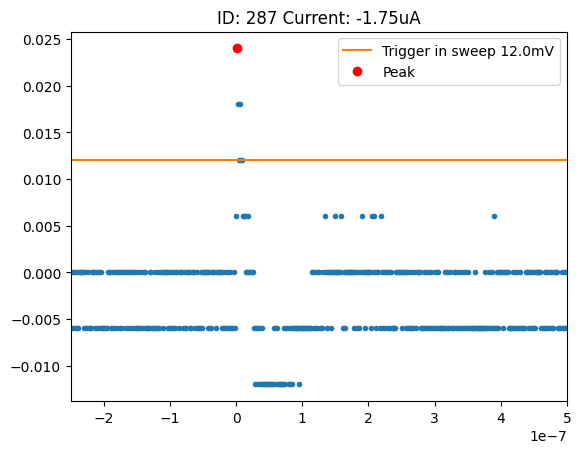

In [85]:
ID = 287
data = load_by_id(ID).get_parameter_data()
trace = data['trace']['trace']
taxis = data['trace']['time_axis']
current = data['yoko_current']['yoko_current']
trigger = data['trigger']['trigger'][0]
plt.plot(taxis, trace, '.')
peaks, properties = find_peaks(trace, height=float(trigger), distance=len(trace))
plt.plot(taxis, np.ones_like(taxis)*float(trigger), label=f'Trigger in sweep {trigger*1e3}mV')
plt.plot(taxis[peaks],trace[peaks], 'ro', label='Peak')
plt.title(f'ID: {ID} Current: {current[0]*1e6}uA')
plt.xlim([-0.25e-6, 0.5e-6])
plt.legend()
# plt.ylabel('Voltage (V)')
# plt.xlabel('Time (s)')
print(current, trace[peaks], 0.8*trace[peaks], 0.2*trace[peaks])
print(f'Peak voltage: {trace[peaks]}')

Several questions: 
1. What is the impact of the minimum vertical resolution on the calculation results? Can I extract a number for minimum step? 
2. Does the minimum vertical resolution change with the vertical scale? 

In [89]:
data['v_scale']['v_scale'][0] # note vertical scale is 25*6

np.float64(0.15)

In [96]:
np.where(np.mod(trace, 0.006)>0)

(array([189, 191]),)

In [99]:
trace[189]/0.006 # effectively 3, remainder should be 0 

np.float64(2.9999999999999996)

In [101]:
trace[191]/0.006 # effectively 3, remainder should be 0

np.float64(2.9999999999999996)

[-1.e-05] [0.228] [0.1824] [0.0456]
Peak voltage: [0.228]


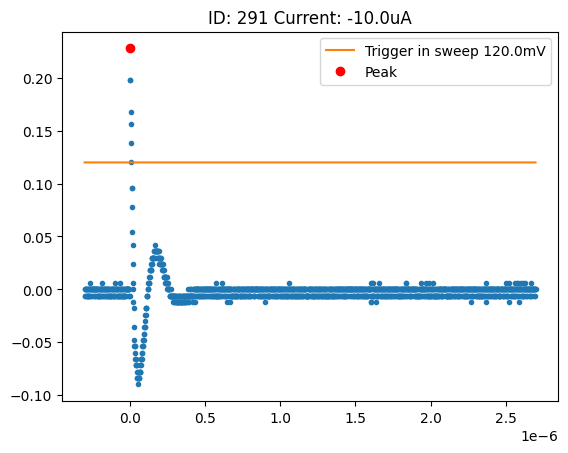

In [103]:
ID = 291
data = load_by_id(ID).get_parameter_data()
trace = data['trace']['trace']
taxis = data['trace']['time_axis']
current = data['yoko_current']['yoko_current']
trigger = data['trigger']['trigger'][0]
plt.plot(taxis, trace, '.')
peaks, properties = find_peaks(trace, height=float(trigger), distance=len(trace))
plt.plot(taxis, np.ones_like(taxis)*float(trigger), label=f'Trigger in sweep {trigger*1e3}mV')
plt.plot(taxis[peaks],trace[peaks], 'ro', label='Peak')
plt.title(f'ID: {ID} Current: {current[0]*1e6}uA')
# plt.xlim([-0.25e-6, 0.5e-6])
plt.legend()
# plt.ylabel('Voltage (V)')
# plt.xlabel('Time (s)')
print(current, trace[peaks], 0.8*trace[peaks], 0.2*trace[peaks])
print(f'Peak voltage: {trace[peaks]}')

In [107]:
LSB_expected = data['v_scale']['v_scale'][0]/25

In [109]:
0.228/LSB_expected # peak is integer multiple of LSB 

np.float64(38.0)

[-1.e-05] [0.2] [0.16] [0.04]
Peak voltage: [0.2]
0.04


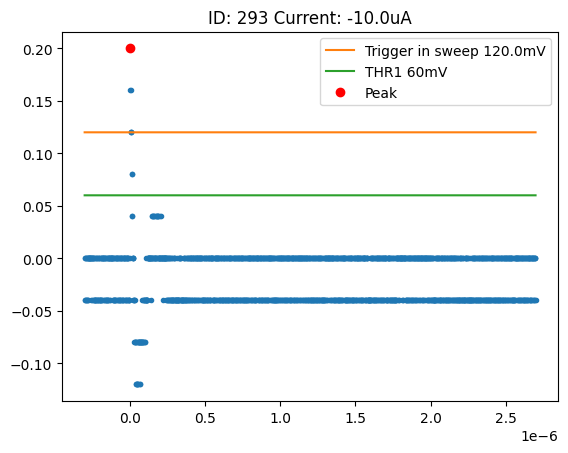

In [118]:
ID = 293
data = load_by_id(ID).get_parameter_data()
trace = data['trace']['trace']
taxis = data['trace']['time_axis']
current = data['yoko_current']['yoko_current']
trigger = data['trigger']['trigger'][0]
plt.plot(taxis, trace, '.')
peaks, properties = find_peaks(trace, height=float(trigger), distance=len(trace))
plt.plot(taxis, np.ones_like(taxis)*float(trigger), label=f'Trigger in sweep {trigger*1e3}mV')
plt.plot(taxis, np.ones_like(taxis)*60e-3, label=f'THR1 60mV')
plt.plot(taxis[peaks],trace[peaks], 'ro', label='Peak')
plt.title(f'ID: {ID} Current: {current[0]*1e6}uA')
# plt.xlim([-0.25e-6, 0.5e-6])
plt.legend()
# plt.ylabel('Voltage (V)')
# plt.xlabel('Time (s)')
print(current, trace[peaks], 0.8*trace[peaks], 0.2*trace[peaks])
print(f'Peak voltage: {trace[peaks]}')
LSB_expected = data['v_scale']['v_scale'][0]/25
print(LSB_expected)

[-1.e-05] [0.24] [0.192] [0.048]
Peak voltage: [0.24]
0.02 [0.5]


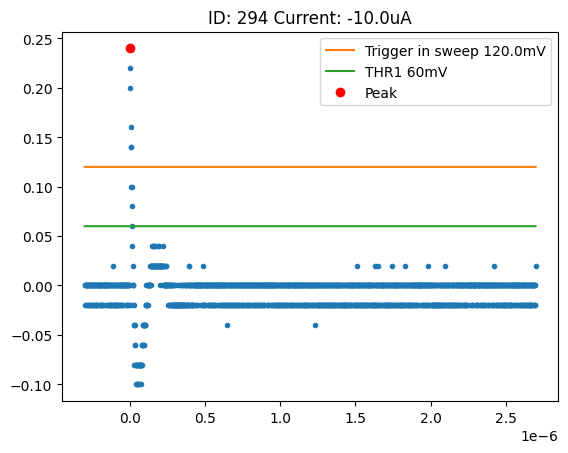

In [120]:

ID = 294
data = load_by_id(ID).get_parameter_data()
trace = data['trace']['trace']
taxis = data['trace']['time_axis']
current = data['yoko_current']['yoko_current']
trigger = data['trigger']['trigger'][0]
plt.plot(taxis, trace, '.')
peaks, properties = find_peaks(trace, height=float(trigger), distance=len(trace))
plt.plot(taxis, np.ones_like(taxis)*float(trigger), label=f'Trigger in sweep {trigger*1e3}mV')
plt.plot(taxis, np.ones_like(taxis)*60e-3, label=f'THR1 60mV')
plt.plot(taxis[peaks],trace[peaks], 'ro', label='Peak')
plt.title(f'ID: {ID} Current: {current[0]*1e6}uA')
# plt.xlim([-0.25e-6, 0.5e-6])
plt.legend()
# plt.ylabel('Voltage (V)')
# plt.xlabel('Time (s)')
print(current, trace[peaks], 0.8*trace[peaks], 0.2*trace[peaks])
print(f'Peak voltage: {trace[peaks]}')
LSB_expected = data['v_scale']['v_scale'][0]/25
print(LSB_expected, data['v_scale']['v_scale'])

[-1.e-05] [0.232] [0.1856] [0.0464]
Peak voltage: [0.232]
0.008 [0.2]


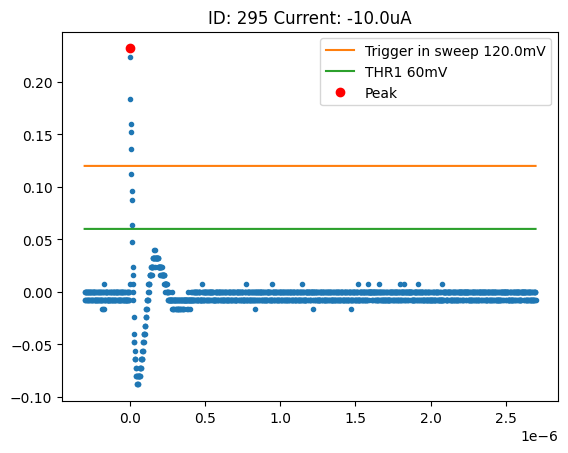

In [123]:

ID = 295
data = load_by_id(ID).get_parameter_data()
trace = data['trace']['trace']
taxis = data['trace']['time_axis']
current = data['yoko_current']['yoko_current']
trigger = data['trigger']['trigger'][0]
plt.plot(taxis, trace, '.')
peaks, properties = find_peaks(trace, height=float(trigger), distance=len(trace))
plt.plot(taxis, np.ones_like(taxis)*float(trigger), label=f'Trigger in sweep {trigger*1e3}mV')
plt.plot(taxis, np.ones_like(taxis)*60e-3, label=f'THR1 60mV')
plt.plot(taxis[peaks],trace[peaks], 'ro', label='Peak')
plt.title(f'ID: {ID} Current: {current[0]*1e6}uA')
# plt.xlim([-0.25e-6, 0.5e-6])
plt.legend()
# plt.ylabel('Voltage (V)')
# plt.xlabel('Time (s)')
print(current, trace[peaks], 0.8*trace[peaks], 0.2*trace[peaks])
print(f'Peak voltage: {trace[peaks]}')
LSB_expected = data['v_scale']['v_scale'][0]/25
print(LSB_expected, data['v_scale']['v_scale'])

[-6.e-06] [0.128] [0.1024] [0.0256]
Peak voltage: [0.128]
0.008 [0.2]


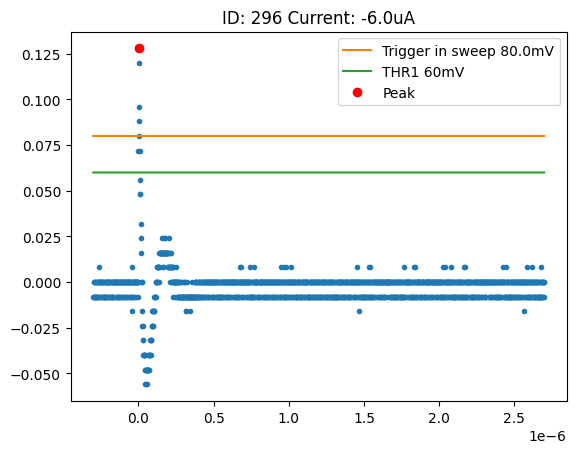

In [122]:

ID = 296
data = load_by_id(ID).get_parameter_data()
trace = data['trace']['trace']
taxis = data['trace']['time_axis']
current = data['yoko_current']['yoko_current']
trigger = data['trigger']['trigger'][0]
plt.plot(taxis, trace, '.')
peaks, properties = find_peaks(trace, height=float(trigger), distance=len(trace))
plt.plot(taxis, np.ones_like(taxis)*float(trigger), label=f'Trigger in sweep {trigger*1e3}mV')
plt.plot(taxis, np.ones_like(taxis)*60e-3, label=f'THR1 60mV')
plt.plot(taxis[peaks],trace[peaks], 'ro', label='Peak')
plt.title(f'ID: {ID} Current: {current[0]*1e6}uA')
# plt.xlim([-0.25e-6, 0.5e-6])
plt.legend()
# plt.ylabel('Voltage (V)')
# plt.xlabel('Time (s)')
print(current, trace[peaks], 0.8*trace[peaks], 0.2*trace[peaks])
print(f'Peak voltage: {trace[peaks]}')
LSB_expected = data['v_scale']['v_scale'][0]/25
print(LSB_expected, data['v_scale']['v_scale'])